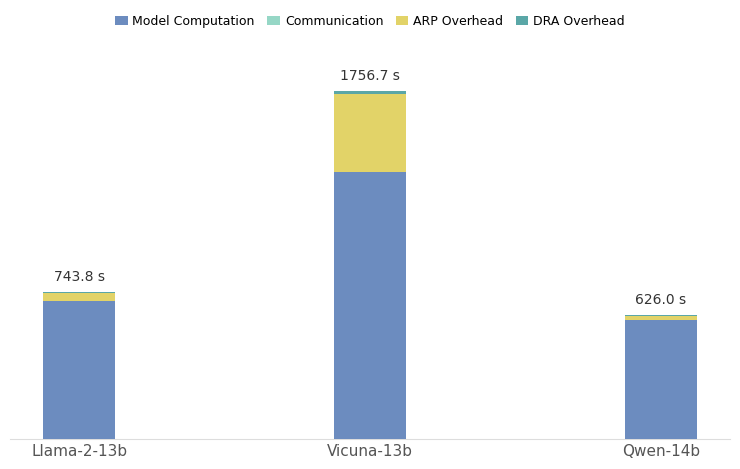

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 数据准备
# ==========================================
data_list = [
    {
        "name": "Llama-2-13b",
        "total": 743.7789,
        "comm": 0.45,
        "arp": 41.13,
        "dra": 6.9776,
    },
    {
        "name": "Vicuna-13b",
        "total": 1756.71,
        "comm": 0.71,
        "arp": 395.67,
        "dra": 11.06,
    },
    {
        "name": "Qwen-14b",
        "total": 626.00,
        "comm": 0.42,
        "arp": 17.81,
        "dra": 4.47,
    },
]

# 提取数据
models = [item["name"] for item in data_list]
total_arr = np.array([item["total"] for item in data_list])
comm_arr = np.array([item["comm"] for item in data_list])
arp_arr = np.array([item["arp"] for item in data_list])
dra_arr = np.array([item["dra"] for item in data_list])

# 计算纯计算时间
compute_arr = total_arr - comm_arr - arp_arr - dra_arr

# ==========================================
# 2. 绘图设置
# ==========================================

fig, ax = plt.subplots(figsize=(8, 5))

# 设置字体
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 12

indices = np.arange(len(models))

# 关键调整：柱子宽度变更细 (0.25)
bar_width = 0.25

# 指定配色 (莫兰迪色系)
# 对应您的要求: #5AA7A7, #E2D368, #6C8CBF, #8AC94A, #96D7C6
color_compute = "#6C8CBF"  # 稳重的灰蓝 -> Model Computation
color_comm = "#96D7C6"  # 清新的薄荷绿 -> Communication
color_arp = "#E2D368"  # 柔和的芥末黄 -> ARP Overhead
color_dra = "#5AA7A7"  # 青色 -> DRA Overhead

# ==========================================
# 3. 绘制堆叠柱状图
# ==========================================

# Layer 1: Computation
ax.bar(
    indices,
    compute_arr,
    bar_width,
    label="Model Computation",
    color=color_compute,
    zorder=3,
)

# Layer 2: Communication
ax.bar(
    indices,
    comm_arr,
    bar_width,
    bottom=compute_arr,
    label="Communication",
    color=color_comm,
    zorder=3,
)

# Layer 3: ARP Overhead
bottom_arp = compute_arr + comm_arr
ax.bar(
    indices,
    arp_arr,
    bar_width,
    bottom=bottom_arp,
    label="ARP Overhead",
    color=color_arp,
    zorder=3,
)

# Layer 4: DRA Overhead
bottom_dra = bottom_arp + arp_arr
ax.bar(
    indices,
    dra_arr,
    bar_width,
    bottom=bottom_dra,
    label="DRA Overhead",
    color=color_dra,
    zorder=3,
)

# ==========================================
# 4. 极简风格去轴处理 (无纵轴)
# ==========================================

# 移除上、左、右边框
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
# 底部边框可以稍微淡一点
ax.spines["bottom"].set_color("#DDDDDD")

# 移除 Y 轴刻度和标签
ax.set_yticks([])
ax.set_ylabel("")

# X 轴设置
ax.set_xticks(indices)
ax.set_xticklabels(models, fontsize=11, color="#555555")  # 字体颜色稍微柔和一点
ax.tick_params(axis="x", length=0)  # 隐藏X轴刻度短线

# 设定Y轴上限
y_max = max(total_arr) * 1.15
ax.set_ylim(0, y_max)

# ==========================================
# 5. 图例与数值
# ==========================================

# 图例放在顶部，扁平化
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.0),
    ncol=4,
    frameon=False,
    fontsize=9,  # 图例字体稍微小一点，更精致
    handletextpad=0.4,
    columnspacing=1.0,
    handlelength=1.0,  # 图例色块变短一点
)

# 顶部数值标注
for i in range(len(models)):
    height = total_arr[i]
    ax.text(
        indices[i],
        height + (y_max * 0.02),
        f"{height:.1f} s",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#333333",
    )

# ==========================================
# 6. 保存
# ==========================================

plt.subplots_adjust(top=0.9, bottom=0.1, left=0.05, right=0.95)

plt.savefig("thinner_bars_no_yaxis.pdf", dpi=300)
plt.savefig("thinner_bars_no_yaxis.png", dpi=300)

plt.show()